## Data Cleaning — Missing Values & Outliers

## 0. Setup & Load Data

In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\ML\claimants.csv")

data = df.copy()
df_clean = df.copy()
df_si = pd.DataFrame(data)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline



In [10]:
# Recreated version of "claimants sample.csv" from the notebook output

data = {
    "CASENUM": [5, 3, 66, 70, 96, 97, 10, 36, 51, 55],
    "CLMSEX": [0, 1, 0, 1, 0, 1, 0, 1, 1, 1],
    "CLMINSUR": [1.0, 0.0, 1.0, 1.0, 1.0, 1.0, np.nan, np.nan, 1.0, 1.0],
    "SEATBELT": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    "CLMAGE": [50.0, 18.0, 5.0, 31.0, 30.0, 35.0, 9.0, 34.0, 60.0, np.nan],
    "LOSS": [34.940, 0.891, 0.330, 0.037, np.nan, 0.309, 3.538, 4.881, 0.874, 0.350],
    "ATTORNEY": [0, 1, 1, 0, 1, 0, 0, 0, 1, 1]
}
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\ML\claimants.csv")
df


,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


## 1. Data Understanding (Always do this first)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   CLMSEX    1328 non-null   float64
 2   CLMINSUR  1299 non-null   float64
 3   SEATBELT  1292 non-null   float64
 4   CLMAGE    1151 non-null   float64
 5   LOSS      1340 non-null   float64
 6   ATTORNEY  1340 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


In [15]:
df.describe()

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
count,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000,1340.000000
mean,11202.001493,0.558735,0.907621,0.017028,28.414422,3.806307,0.488806
std,9512.750796,0.496725,0.289671,0.129425,20.304451,10.636903,0.500061
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,1.000000,0.000000,9.000000,0.400000,0.000000
50%,8756.500000,1.000000,1.000000,0.000000,30.000000,1.069500,0.000000
75%,15702.500000,1.000000,1.000000,0.000000,43.000000,3.781500,1.000000
max,34153.000000,1.000000,1.000000,1.000000,95.000000,173.604000,1.000000


In [16]:
#Missing value count per column
df.isnull().sum()

CASENUM       0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
ATTORNEY      0
dtype: int64

## 2.Missing Value Handling

# 2.1 Method 1 — Remove rows with missing values

In [17]:
df = df.dropna() # removes ANY row containing at least one NaN
df

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...
1334,34104,1.0,1.0,0.0,16.0,0.060,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


In [18]:
df.isnull().sum()# confirm no missing values remain

CASENUM     0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
ATTORNEY    0
dtype: int64

# 2.2 Method 2 — Replace (Imputation) usingfillna()

In [19]:
mean = df["CLMAGE"].mean()
median = df["LOSS"].median()
mode = df["CLMINSUR"].mode()[0]
print("Mean CLMAGE:", mean)
print("Median LOSS:", median)
print("Mode CLMINSUR:", mode)

Mean CLMAGE: 28.587591240875913
Median LOSS: 1.311
Mode CLMINSUR: 1.0


In [26]:
df['CLMAGE'] = df['CLMAGE'].fillna(mean)
df["LOSS"] = df["LOSS"].fillna(median)
df["CLMINSUR"] = df["CLMINSUR"].fillna(mode)

df.isnull().sum() # all zeros now

CASENUM      0
CLMSEX      12
CLMINSUR     0
SEATBELT    48
CLMAGE       0
LOSS         0
ATTORNEY     0
dtype: int64

# 2.3 Method 3 —SimpleImputer from scikit-learn

In [21]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
print(df_si)

      CASENUM  CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS  ATTORNEY
0           5     0.0       1.0       0.0    50.0  34.940         0
1           3     1.0       0.0       0.0    18.0   0.891         1
2          66     0.0       1.0       0.0     5.0   0.330         1
3          70     0.0       1.0       1.0    31.0   0.037         0
4          96     0.0       1.0       0.0    30.0   0.038         1
...       ...     ...       ...       ...     ...     ...       ...
1335    34100     0.0       1.0       0.0     NaN   0.576         1
1336    34110     1.0       1.0       0.0    46.0   3.705         0
1337    34113     1.0       1.0       0.0    39.0   0.099         1
1338    34145     1.0       0.0       0.0     8.0   3.177         0
1339    34153     1.0       1.0       0.0    30.0   0.688         1

[1340 rows x 7 columns]


In [35]:

print(list(df_si.columns))

['CASENUM', 'CLMSEX', 'CLMINSUR', 'SEATBELT', 'CLMAGE', 'LOSS', 'ATTORNEY']


In [36]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')
df_si['LOSS'] = mean_imputer.fit_transform(df_si[['LOSS']])

median_imputer = SimpleImputer(strategy='median')
df_si['CLMAGE'] = median_imputer.fit_transform(df_si[['CLMAGE']])

mode_imputer = SimpleImputer(strategy='most_frequent')
df_si['CLMINSUR'] = mode_imputer.fit_transform(df_si[['CLMINSUR']])

print(df_si.isnull().sum())

CASENUM      0
CLMSEX      12
CLMINSUR     0
SEATBELT    48
CLMAGE       0
LOSS         0
ATTORNEY     0
dtype: int64


# 3. Outlier Detection

In [37]:
# Fresh dataset with NaNs (to mirror original outlier section, which re-loads the raw data)
import pandas as pd
df = pd.DataFrame(data)
df

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


# 3.1 IQR Method

In [38]:
Q1 = df['LOSS'].quantile(0.25)
Q3 = df['LOSS'].quantile(0.75)
IQR = Q3-Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 0.4
Q3: 3.7815
IQR: 3.3815


In [40]:
l_limit = Q1-(1.5 * IQR)
u_limit = Q3 + (1.5 * IQR)
print("Lower limit:", l_limit)
print("Upper limit:", u_limit)

Lower limit: -4.67225
Upper limit: 8.85375


# 3.2 Boxplot Visualization

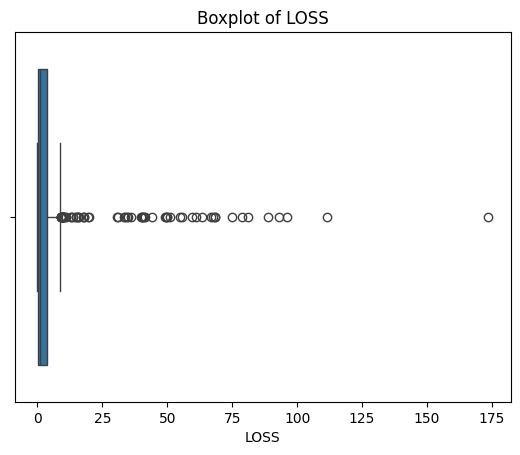

In [41]:
sns.boxplot(x=df['LOSS'])
plt.title("Boxplot of LOSS")
plt.show()

# 3.3 Histogram Visualization

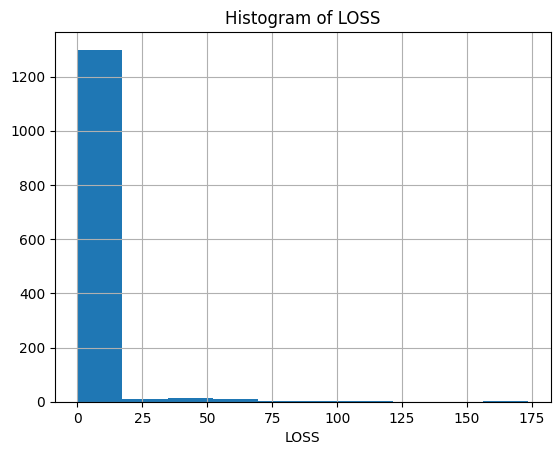

In [42]:
df['LOSS'].hist()
plt.title("Histogram of LOSS")
plt.xlabel("LOSS")
plt.show()

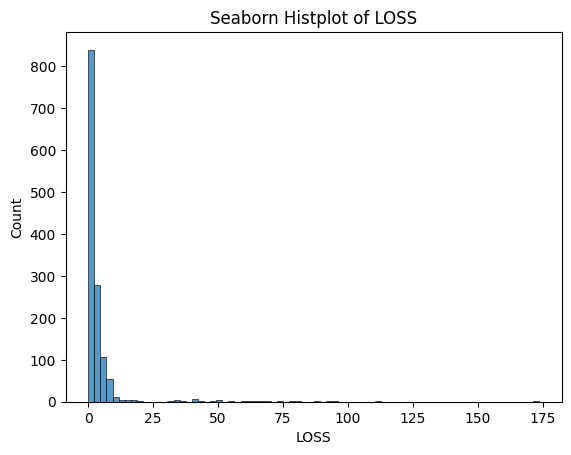

In [43]:
sns.histplot(x=df['LOSS'])
plt.title("Seaborn Histplot of LOSS")
plt.show()


# 3.4 Z-score Method

In [45]:

mu = df['LOSS'].mean()
st = df['LOSS'].std()
print("Mean:", mu, "| Std:", st)

Mean: 3.8063067164179105 | Std: 10.63690317364136


In [46]:

df['loss_zscore'] = (df['LOSS']- mu) / st
df[['LOSS', 'loss_zscore']]

,LOSS,loss_zscore
0,34.940,2.926951
1,0.891,-0.274075
2,0.330,-0.326816
3,0.037,-0.354361
4,0.038,-0.354267
...,...,...
1335,0.576,-0.303689
1336,3.705,-0.009524
1337,0.099,-0.348533
1338,3.177,-0.059163


In [47]:
outliers = df[(df['loss_zscore'] > 2) | (df['loss_zscore'] <-2)]
outliers

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY,loss_zscore
0,5,0.0,1.0,0.0,50.0,34.940,0,2.926951
55,195,0.0,1.0,0.0,30.0,33.633,0,2.804077
70,607,0.0,1.0,0.0,56.0,44.060,0,3.784343
97,1054,0.0,1.0,0.0,1.0,34.571,0,2.892260
106,1315,0.0,1.0,0.0,19.0,40.364,0,3.436874
147,3531,0.0,1.0,0.0,6.0,49.560,0,4.301411
148,3546,1.0,1.0,0.0,40.0,59.497,0,5.235612
156,3699,0.0,1.0,0.0,17.0,33.451,0,2.786967
157,3707,1.0,1.0,0.0,13.0,40.460,0,3.445899
242,6080,0.0,1.0,0.0,41.0,40.000,0,3.402653


In [48]:
# Drop helper column once done
df.drop('loss_zscore', axis=1, inplace=True)
df

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


# 4. Dealing with Outliers

# 4.1 Trimming (Remove)

In [49]:
df_trimmed = df[(df['LOSS'] > l_limit) & (df['LOSS'] < u_limit)]
df_trimmed

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
5,97,1.0,1.0,0.0,35.0,0.309,0
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


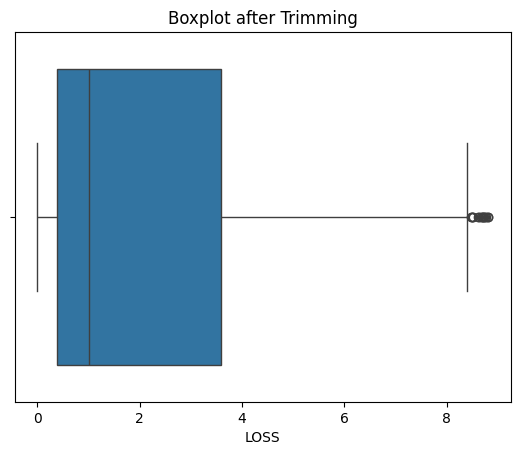

In [50]:

sns.boxplot(x=df_trimmed['LOSS'])
plt.title("Boxplot after Trimming")
plt.show()

# 4.2 Winsorization (Cap with feature_engine )

In [51]:
# Drop remaining NaNs before winsorizing (Winsorizer can't handle missing values)
df_clean = df.dropna()
df_clean.isnull().sum()

CASENUM     0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
ATTORNEY    0
dtype: int64

In [52]:
%pip install feature-engine


  Using cached feature_engine-1.9.4-py3-none-any.whl.metadata (10 kB)
Using cached feature_engine-1.9.4-py3-none-any.whl (243 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from feature_engine.outliers import Winsorizer

In [11]:
from feature_engine.outliers import Winsorizer
win = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=['LOSS'])
df_win = win.fit_transform(df_clean[['LOSS']])
df_win

,LOSS
0,8.85375
1,0.89100
2,0.33000
3,0.03700
4,0.03800
...,...
1335,0.57600
1336,3.70500
1337,0.09900
1338,3.17700


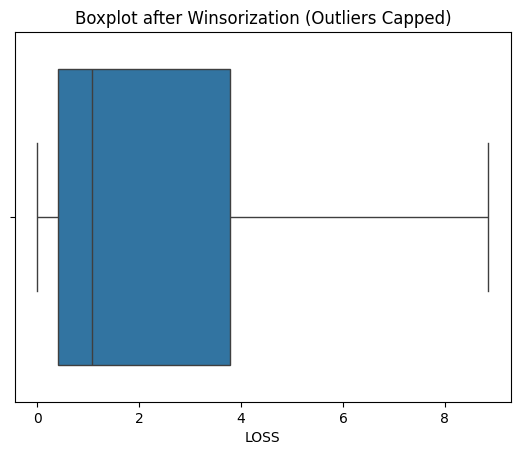

In [12]:
sns.boxplot(x=df_win['LOSS'])
plt.title("Boxplot after Winsorization (Outliers Capped)")
plt.show()